# Module 10. Big data
# Fitting data in memory
## Lecture objectives

1. Introduce some of the strategies to handle large data sets
2. Discuss how data types affect memory requirements
3. Demonstrate how to sample to reduce the size of a dataset

Big data is often characterized by the 3 "Vs": velocity, volume, and variety.

We've talked implicitly about the **variety** throughout the course — how to clean, join, and otherwise wrangle datasets. Here, we'll focus on issues of **volume**. In short, what can you do when a dataset doesn't fit into memory, or your code takes too long to run.

Here, I'll set out a hierarchy of approaches to dealing with large datasets. Start with the simplest, and move on to the next group of solutions as needed.

* Testing and scaling up
* Running overnight
* Finding a secondary computer
* Profiling
* Being economical with data types
* Sampling

These strategies are all about being efficient and thoughtful with your analysis. They don't need any special procedures or coding, and some of the strategies are self explanatory.

*Testing and scaling up*: get your code working on a tiny subset of the data, before running it on your full dataset. This seems obvious, but will save you a lot of time. For example: run your code on Ventura County data before doing Los Angeles County, or take a small city in the county.

*Running overnight*: Again, this seems obvious. But remember: your time is much more valuable than the computer's. You could spend the time to make your code more efficient, or you could just leave your computer running in the kitchen or in a closet while you sleep / go to the beach / do something fun.

*Finding a secondary computer*: Maybe you have an old laptop with a cracked screen, an erratic keyboard, and a battery that holds about 15 minutes of charge? This is the perfect machine to do some web scraping or similar tasks in the background. Leave it running for a few days/weeks/months and plug in an external hard drive. 

*Profiling*: identify bottlenecks in your code. We'll discuss this in the next lecture.

In this lecture, we'll focus on fitting large datasets in memory, through judicious use of *data types* and *sampling*.

### Being economical with data types

Data types refer to how an object (integer, string, etc.) is stored by Python. `pandas` generally uses the underlying `numpy` data types, [which are described here](https://numpy.org/doc/stable/user/basics.types.html).

Why should you care about data types? Often, it doesn't matter - if you have integers, storing them as a float will usually work just as well. But we've seen several instances where we need to convert the data type.

In particular, numbers can be stored as strings, but we need to convert them to integers or floats to do arithmetic.

And census geoidentifiers (e.g. tract) can be stored as numbers, but that loses the leading zero, so they are hard to join if one table has the geoid as a string.

In [1]:
x = '1'
y = '2'
print(x*y)  # fails because they are strings

TypeError: can't multiply sequence by non-int of type 'str'

In [2]:
print(int(x)*int(y))   # converting to integer works

2


The other major time when you have to worry about data types is to increase the efficiency of your data storage. In general, the order from most- to least-efficient is:
* boolean (True or False)
* integer
* float
* string / object

The relevant consideration is how many *bits* they consume. For example, an integer can be represented in various ways:
* `int64` is the default, which can represent integers from  from -9223372036854775808 to +9223372036854775807 
* `int32` consumes half as much space, but can only represent -2147483648 to +2147483647
* `int16` and `int8` are also possibilities, if you are sure that you won't have large numbers
* You can also have unsigned integers (positive numbers only)

Similar logic applies to floats: `float64`, `float32`, etc. Here, it's the precision rather than the range that's affected.

We can use `info()` to get the memory consumption of a dataframe. Let's compare the different data types.

In [3]:
import pandas as pd
import numpy as np

# create a dataframe with one column of ones
df = pd.DataFrame(np.ones(50000), columns=['ones'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ones    50000 non-null  float64
dtypes: float64(1)
memory usage: 390.8 KB


<div class="alert alert-block alert-info">
    <strong>Exercise:</strong> Suppose you change the datatype to <strong>int16</strong> or <strong>int8</strong>. How would that affect memory usage?
</div>

In [4]:
df['ones'] = df.ones.astype('int8')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ones    50000 non-null  int8 
dtypes: int8(1)
memory usage: 49.0 KB


We reduce the size of our dataframe from 391k to 49k – an eightfold reduction (which makes sense as we are going from 64 bit to 8 bit).

Here's a less trivial example, using the voting dataset that we used before.

In [5]:
df = pd.read_csv('../data/c037_g20_sov_data_by_g20_srprec.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4313 entries, 0 to 4312
Data columns (total 73 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   county    4313 non-null   int64 
 1   srprec    4313 non-null   object
 2   addist    4313 non-null   int64 
 3   cddist    4313 non-null   int64 
 4   sddist    4313 non-null   int64 
 5   bedist    4313 non-null   int64 
 6   TOTREG    4313 non-null   int64 
 7   DEMREG    4313 non-null   int64 
 8   REPREG    4313 non-null   int64 
 9   AIPREG    4313 non-null   int64 
 10  GRNREG    4313 non-null   int64 
 11  LIBREG    4313 non-null   int64 
 12  NLPREG    4313 non-null   int64 
 13  REFREG    4313 non-null   int64 
 14  DCLREG    4313 non-null   int64 
 15  MSCREG    4313 non-null   int64 
 16  TOTVOTE   4313 non-null   int64 
 17  DEMVOTE   4313 non-null   int64 
 18  REPVOTE   4313 non-null   int64 
 19  AIPVOTE   4313 non-null   int64 
 20  GRNVOTE   4313 non-null   int64 
 21  LIBVOTE   4313

<div class="alert alert-block alert-info">
    <strong>Exercise:</strong> What's the smallest (most efficient) data type that you could use for these columns?
</div>

Let's look at the maximum number of votes per precinct, to see what data type might be appropriate.

Here, we use `.max()` to get the maximum value within each column (after dropping the non-numeric `srprec` column), and then `.max()` again to get the maximum across columns.

In [6]:
df.drop(columns=['srprec']).max()

county          19
addist      223199
cddist      147134
sddist      114654
bedist       11304
             ...  
SENAIP01     89080
SENDEM01    972397
SENDEM02    164752
SENLIB01         0
SENREP01    414172
Length: 72, dtype: int64

In [7]:
df.drop(columns=['srprec']).max().max()

5709853

That won't fit into `int16` (-32767 to +32767), but we could use `int32`.

In [8]:
for col in df.columns:
    if df[col].dtype != 'object': # skip the string column (srprec)
        df[col] = df[col].astype('int32')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4313 entries, 0 to 4312
Data columns (total 73 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   county    4313 non-null   int32 
 1   srprec    4313 non-null   object
 2   addist    4313 non-null   int32 
 3   cddist    4313 non-null   int32 
 4   sddist    4313 non-null   int32 
 5   bedist    4313 non-null   int32 
 6   TOTREG    4313 non-null   int32 
 7   DEMREG    4313 non-null   int32 
 8   REPREG    4313 non-null   int32 
 9   AIPREG    4313 non-null   int32 
 10  GRNREG    4313 non-null   int32 
 11  LIBREG    4313 non-null   int32 
 12  NLPREG    4313 non-null   int32 
 13  REFREG    4313 non-null   int32 
 14  DCLREG    4313 non-null   int32 
 15  MSCREG    4313 non-null   int32 
 16  TOTVOTE   4313 non-null   int32 
 17  DEMVOTE   4313 non-null   int32 
 18  REPVOTE   4313 non-null   int32 
 19  AIPVOTE   4313 non-null   int32 
 20  GRNVOTE   4313 non-null   int32 
 21  LIBVOTE   4313

So we halve the memory usage. Let's check to see whether our data is unaffected.

In [9]:
df.drop(columns=['srprec']).max().max()

5709853

That wouldn't be the case if we converted to (say) `int16`. Beware!

In [10]:
print(df['SENDEM01'].max())
print(df['SENDEM01'].astype('int16').max())
#data typeをint16にすると最大値はぐっと下がる
#ここでエラーが出ない事から分かるように、
#データを小さくしようと思ってdata typeをint16などに切り下げた場合、
#データが失われているにもかかわらずエラーが出ないので要注意
#データを小さくするためにdata typeを変える場合には、すべての変数について最大値を確認して
#データが失われる事のないように注意すべし

972397
2175


Note that `pandas` can skip columns, skip rows, and force particular data types when reading in a `csv` file. Check out the options.

In [ ]:
#上のようにdata typeを変更する以外のデータの圧縮方法として、読み込む変数を絞る、という方法がある
#例えば大きなcsvファイルを読み込む場合、丸ごと読み込むととても重い
#そこで、特定の変数だけを読み込むことで、dataframeを軽くできる（read_csv?を見ると色々なargumentがある事が分かる）
pd.read_csv?

For example, we could read only the Proposition 14 (yes/no) and precinct columns, and read the numeric columns as `int32`.

The `usecols` argument gives us the subset of columns. The `dtype` argument is a dictionary of data types.

Note that we don't specify a type for `PR_14_Y`, so it gets read in as `int64`.

In [11]:
df = pd.read_csv('../data/c037_g20_sov_data_by_g20_srprec.csv', 
                 usecols=['srprec', 'PR_14_N', 'PR_14_Y'],
                 dtype={'srprec':'str', 'PR_14_N':'int32'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4313 entries, 0 to 4312
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   srprec   4313 non-null   object
 1   PR_14_N  4313 non-null   int32 
 2   PR_14_Y  4313 non-null   int64 
dtypes: int32(1), int64(1), object(1)
memory usage: 84.4+ KB


### Sampling
Sampling is often useful because there are diminishing returns (in terms of predictive power) to the size of your dataset. In statistical terms, remember that your standard errors go down by $1/\sqrt{N}$, not by $1/N$.

So if you have a million observations, you *might* get similar results through using a sample of half that size. This is likely to be the case for statistical models (e.g. logistic regression). It might not hold for machine learning models which are more flexible in the way that they consider interactions.

Let's recreate the ADU prediction model that we saw in the classification notebook a couple of weeks ago.

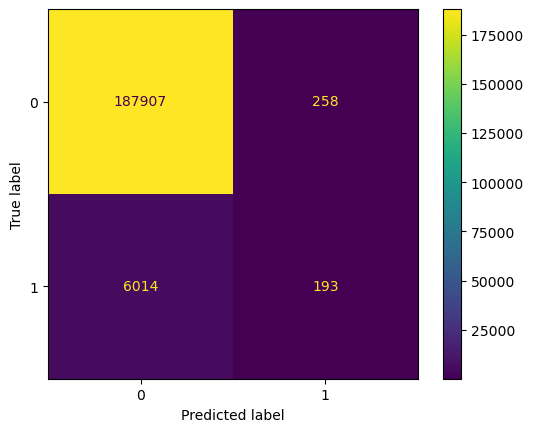

In [12]:
# all this code is identical to what we had before

# read in and join parcels and permits
permits = pd.read_csv('../data/ADUs/ADU_permits.csv') 
parcels = pd.read_csv('../data/ADUs/parcels.csv')
permits.dropna(subset=['Assessor Book', 'Assessor Page','Assessor Parcel'], inplace=True)
permits = permits[permits['Assessor Parcel']!='***']
permits['APN'] = (permits['Assessor Book'].astype(int).astype(str).str.zfill(4) + '-' 
                   + permits['Assessor Page'].astype(int).astype(str).str.zfill(3) + '-'
                   + permits['Assessor Parcel'].astype(int).astype(str).str.zfill(3))
permits = permits.groupby('APN').first()
parcels = parcels.groupby('APN').first()
joinedDf = parcels.join(permits, how='left')

# add dependent variable
joinedDf['hasADU'] = joinedDf['# of Accessory Dwelling Units'].apply(lambda x: 0 if pd.isnull(x) else 1)

# split the data and fit the model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

xvars =  ['YearBuilt1', 'Units1', 'Bedrooms1', 'Bathrooms1', 'SQFTmain1', 'Roll_LandValue', 
         'Roll_ImpValue','CENTER_LAT', 'CENTER_LON']
yvar = 'hasADU'
df_to_fit = joinedDf[xvars+[yvar]].dropna()
X_train, X_test, y_train, y_test = train_test_split(df_to_fit[xvars], df_to_fit[yvar], test_size = 0.25, random_state = 1)

rf = RandomForestClassifier(n_estimators = 10, random_state = 1)  # 10 trees to save time
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

What if we just estimate this model on half the data? We can use the `sample` function in `pandas`.

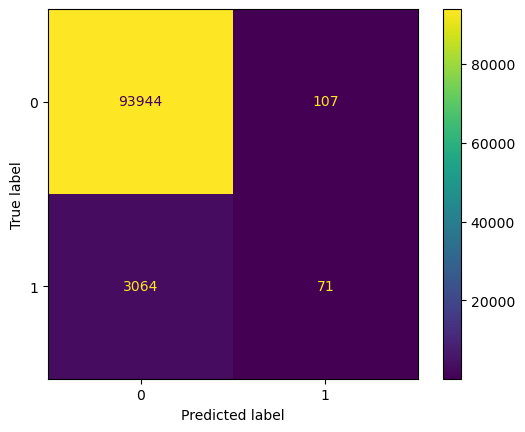

In [13]:
df_to_fit = df_to_fit.sample(frac=0.5) # take 50% sample
    
# this code is identical
X_train, X_test, y_train, y_test = train_test_split(df_to_fit[xvars], df_to_fit[yvar], test_size = 0.25, random_state = 1)

rf = RandomForestClassifier(n_estimators = 10, random_state = 1)  # 10 estimators to save time
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

This isn't so bad. (Remember all of the entries in the confusion matrix should have half the observations, because we have half the sample size.)

However, a better way forward here might be to:
1. Estimate the model on a sample of the data
2. Look at the feature importances
3. Run the model on the full data, but excluding some of the variables that don't increase predictive performance (i.e., low importance)

I'll leave that for you as an exercise.

##### まとめると（データを軽くする方法）
- data typeを軽いもの（int32など）に変える
- loadingする変数を絞る
- samplingをする（sampleを使ってモデルを予測して、feature importanceを同定し、データ全体に対してはすべての変数をloadingするのではなくfeature importanceに選ばれた変数だけをloadingする）

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
  <li>Start simple! Most "big" datasets can be handled on any laptop through judicious use of datatypes, and working on a chunk of your data at one time.</li>
    <li>You will rarely need to do more than this, but the UCLA Hoffman2 cluster and cloud service providers are there if you need them.</li>
</ul>
</div>